## Setup

Import required Python libraries and define project directories for:
- MD trajectories
- analysis results
- generated figures

Create output directories if they do not yet exist.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.analysis import rms

BASE = Path("..")
DATA = BASE / "data" / "md"
RESULTS = BASE / "results" / "md_analysis"
FIGURES = BASE / "figures" / "md_analysis"

RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

/rwthfs/rz/cluster/home/dwp46550/ba_nylon/envs/ba_nylc/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Metadata generation

Automatically parse the MD simulation directory structure and generate a structured metadata table describing:
- variant
- simulation condition
- replicate number
- trajectory files
- topology/reference files
- system type

The resulting metadata table serves as the central dataset index for all subsequent MD analyses.

In [2]:
from pathlib import Path
import re
import pandas as pd

base = Path("..") / "data" / "md"
rows = []

for variant_dir in sorted(base.iterdir()):
    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name

    for condition_dir in sorted(variant_dir.iterdir()):
        if not condition_dir.is_dir():
            continue

        condition = condition_dir.name

        for xtc in sorted(condition_dir.glob("md_center_*.xtc")):
            m = re.search(r"md_center_(\d+)\.xtc$", xtc.name)
            if not m:
                continue

            rep = int(m.group(1))

            pdb = condition_dir / f"md_center_{rep}.pdb"
            chains_pdb = condition_dir / f"md_center_{rep}_chains.pdb"

            tpr_ligand = condition_dir / f"md_protein_ligand_{rep}.tpr"
            tpr_protein = condition_dir / f"md_protein_{rep}.tpr"

            if tpr_ligand.exists():
                tpr = tpr_ligand
                system_type = "protein_ligand"
            elif tpr_protein.exists():
                tpr = tpr_protein
                system_type = "protein"
            else:
                tpr = None
                system_type = "unknown"

            rows.append({
                "variant": variant,
                "condition": condition,
                "replicate": rep,
                "system_type": system_type,
                "xtc_path": str(xtc),
                "pdb_path": str(pdb) if pdb.exists() else "",
                "chains_pdb_path": str(chains_pdb) if chains_pdb.exists() else "",
                "tpr_path": str(tpr) if tpr is not None else "",
                "has_xtc": xtc.exists(),
                "has_pdb": pdb.exists(),
                "has_chains_pdb": chains_pdb.exists(),
                "has_tpr": tpr is not None,
            })

df = pd.DataFrame(rows)
df = df.sort_values(["variant", "condition", "replicate"])
out = RESULTS / "md_metadata.csv"
out.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out, index=False)

print(df)
print(f"\nSaved: {out}")

                   variant     condition  replicate     system_type  \
0                     D99R  no_substrate          1         protein   
1                     D99R  no_substrate          2         protein   
2                     D99R  no_substrate          3         protein   
3   D99R_f134w_d304m_r330a       ace_coo          1  protein_ligand   
4   D99R_f134w_d304m_r330a       ace_coo          2  protein_ligand   
5   D99R_f134w_d304m_r330a       ace_coo          3  protein_ligand   
6                       WT       ace_coo          1  protein_ligand   
7                       WT       ace_coo          2  protein_ligand   
8                       WT       ace_coo          3  protein_ligand   
9        f134w_d304m_r330a       ace_coo          1  protein_ligand   
10       f134w_d304m_r330a       ace_coo          2  protein_ligand   
11       f134w_d304m_r330a       ace_coo          3  protein_ligand   

                                             xtc_path  \
0        ../data/md

## Load metadata table

Load the previously generated metadata table containing all detected MD simulation systems and associated trajectory/topology files.

In [3]:
metadata = pd.read_csv(RESULTS / "md_metadata.csv")

metadata.head()

,variant,condition,replicate,system_type,xtc_path,pdb_path,chains_pdb_path,tpr_path,has_xtc,has_pdb,has_chains_pdb,has_tpr
0,D99R,no_substrate,1,protein,../data/md/D99R/no_substrate/md_center_1.xtc,../data/md/D99R/no_substrate/md_center_1.pdb,../data/md/D99R/no_substrate/md_center_1_chain...,../data/md/D99R/no_substrate/md_protein_1.tpr,True,True,True,True
1,D99R,no_substrate,2,protein,../data/md/D99R/no_substrate/md_center_2.xtc,../data/md/D99R/no_substrate/md_center_2.pdb,../data/md/D99R/no_substrate/md_center_2_chain...,../data/md/D99R/no_substrate/md_protein_2.tpr,True,True,True,True
2,D99R,no_substrate,3,protein,../data/md/D99R/no_substrate/md_center_3.xtc,../data/md/D99R/no_substrate/md_center_3.pdb,../data/md/D99R/no_substrate/md_center_3_chain...,../data/md/D99R/no_substrate/md_protein_3.tpr,True,True,True,True
3,D99R_f134w_d304m_r330a,ace_coo,1,protein_ligand,../data/md/D99R_f134w_d304m_r330a/ace_coo/md_c...,../data/md/D99R_f134w_d304m_r330a/ace_coo/md_c...,../data/md/D99R_f134w_d304m_r330a/ace_coo/md_c...,../data/md/D99R_f134w_d304m_r330a/ace_coo/md_p...,True,True,True,True
4,D99R_f134w_d304m_r330a,ace_coo,2,protein_ligand,../data/md/D99R_f134w_d304m_r330a/ace_coo/md_c...,../data/md/D99R_f134w_d304m_r330a/ace_coo/md_c...,../data/md/D99R_f134w_d304m_r330a/ace_coo/md_c...,../data/md/D99R_f134w_d304m_r330a/ace_coo/md_p...,True,True,True,True


## Select reference simulation

Select the WT / ace_coo / replicate 1 simulation system as the initial reference trajectory for workflow validation and exploratory MD analysis.

In [4]:
row = metadata.query(
    "variant == 'WT' and condition == 'ace_coo' and replicate == 1"
).iloc[0]

row

variant                                                       WT
condition                                                ace_coo
replicate                                                      1
system_type                                       protein_ligand
xtc_path                   ../data/md/WT/ace_coo/md_center_1.xtc
pdb_path                   ../data/md/WT/ace_coo/md_center_1.pdb
chains_pdb_path     ../data/md/WT/ace_coo/md_center_1_chains.pdb
tpr_path           ../data/md/WT/ace_coo/md_protein_ligand_1.tpr
has_xtc                                                     True
has_pdb                                                     True
has_chains_pdb                                              True
has_tpr                                                     True
Name: 6, dtype: object

## Load MD trajectory

Load the selected simulation system into an MDAnalysis Universe using:
- the chain-preserving reference PDB structure
- the centered trajectory (.xtc)

The chains_pdb file is used instead of the .tpr topology in order to preserve biologically meaningful residue numbering and chain annotations.

In [18]:
u = mda.Universe(
    row["chains_pdb_path"],
    row["xtc_path"]
)
ut = mda.Universe(
    row["tpr_path"],
    row["xtc_path"]
)
print(u)

print("Atoms:", u.atoms.n_atoms)
print("Residues:", len(u.residues))
print("Frames:", len(u.trajectory))

print(
    "Segments:",
    [seg.segid for seg in u.segments]
)

/rwthfs/rz/cluster/home/dwp46550/ba_nylon/envs/ba_nylc/lib64/python3.9/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


<Universe with 19405 atoms>
Atoms: 19405
Residues: 1337
Frames: 6349
Segments: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


## Residue numbering validation

Functionally important catalytic and mutational residues were inspected to verify whether biologically meaningful residue numbering was preserved after loading the trajectory.

Initial tests revealed inconsistent residue identities when using the .tpr topology, indicating that the original biological residue numbering was not preserved in the GROMACS topology representation.

In [20]:
important_residues = [99, 134, 267, 304, 306, 308, 330]

print("Initial residue validation using TPR-based topology\n")

for resid in important_residues:

    sel = ut.select_atoms(
        f"protein and resid {resid}"
    )

    print(
        f"Resid {resid}",
        "| atoms:", sel.n_atoms,
        "| residue names:",
        list(set(sel.residues.resnames))
    )

print("\nExpected WT residues:")
print("99  -> ASP")
print("134 -> PHE")
print("267 -> THR")
print("304 -> ASP")
print("306 -> ASP")
print("308 -> ASP")
print("330 -> ARG")
print("\n")
print("Residue validation using PDB-based topology\n")

for resid in important_residues:

    sel = u.select_atoms(f"protein and resid {resid}")

    print(
        f"Resid {resid}",
        "| atoms:", sel.n_atoms,
        "| residue names:", list(set(sel.residues.resnames))
    )

Initial residue validation using TPR-based topology

Resid 99 | atoms: 10 | residue names: ['ALA']
Resid 134 | atoms: 24 | residue names: ['ARG']
Resid 267 | atoms: 16 | residue names: ['VAL']
Resid 304 | atoms: 11 | residue names: ['SER']
Resid 306 | atoms: 7 | residue names: ['GLY']
Resid 308 | atoms: 19 | residue names: ['LEU']
Resid 330 | atoms: 10 | residue names: ['ALA']

Expected WT residues:
99  -> ASP
134 -> PHE
267 -> THR
304 -> ASP
306 -> ASP
308 -> ASP
330 -> ARG


Residue validation using PDB-based topology

Resid 99 | atoms: 48 | residue names: ['ASP']
Resid 134 | atoms: 80 | residue names: ['PHE']
Resid 267 | atoms: 60 | residue names: ['THR']
Resid 304 | atoms: 48 | residue names: ['ASP']
Resid 306 | atoms: 48 | residue names: ['ASP']
Resid 308 | atoms: 48 | residue names: ['ASP']
Resid 330 | atoms: 96 | residue names: ['ARG']


## Chain organization analysis

Inspect the chain and segment organization of the loaded simulation system in order to:
- identify biologically relevant chains
- validate multimeric organization
- enable chain-specific residue selections for subsequent analyses

In [ ]:
for seg in u.segments:
    print(seg.segid, len(seg.atoms), len(seg.residues))

print(set(u.atoms.chainIDs))

A 3478 243
B 1323 89
C 3537 247
D 1323 89
E 3478 243
F 1323 89
G 3537 247
H 1406 90
{'A', 'C', 'B', 'E', 'F', 'D', 'H', 'G'}


## Chain-specific residue validation

Perform chain-specific residue selections to validate that catalytically relevant residues can be uniquely identified within the multimeric simulation system.

In [10]:
sel = u.select_atoms("protein and chainID B and resid 267")
print(sel.n_atoms, sel.residues.resnames)

15 ['THR']


## Inspection of chain-independent residue selection

Inspect all residues returned by a chain-independent residue selection in order to verify whether identical residue numbers occur across multiple chains of the multimeric system.

In [12]:
u.select_atoms("protein and resid 267").residues

<ResidueGroup with 4 residues>

## Validation of catalytically relevant residues

Validate the identity and structural accessibility of functionally important catalytic and mutational residues using chain-specific residue selections.

The following residues were inspected:
- mutation sites
- catalytic residues
- active-site neighboring residues

In [ ]:
important_sites = [
    ("A", 99),
    ("A", 134),
    ("B", 267),
    ("B", 304),
    ("B", 306),
    ("B", 308),
    ("B", 330),
]

for chain, resid in important_sites:
    sel = u.select_atoms(f"protein and chainID {chain} and resid {resid}")
    print(
        f"{chain}{resid}",
        "| atoms:", sel.n_atoms,
        "| residue names:", list(set(sel.residues.resnames))
    )

A99 | atoms: 12 | residue names: ['ASP']
A134 | atoms: 20 | residue names: ['PHE']
B267 | atoms: 15 | residue names: ['THR']
B304 | atoms: 12 | residue names: ['ASP']
B306 | atoms: 12 | residue names: ['ASP']
B308 | atoms: 12 | residue names: ['ASP']
B330 | atoms: 24 | residue names: ['ARG']


## Observation

All inspected catalytic and mutational residues matched the expected WT sequence.

Validated residues:
- A99  → ASP
- A134 → PHE
- B267 → THR
- B304 → ASP
- B306 → ASP
- B308 → ASP
- B330 → ARG

This confirms:
- correct preservation of biological residue numbering
- successful chain annotation
- correct identification of the catalytic region

The simulation system is therefore considered structurally validated for subsequent dynamical analyses.

## Backbone RMSD analysis

Backbone RMSD was calculated relative to the first trajectory frame in order to assess the global structural stability of the simulation system.

Only protein backbone atoms were included in the analysis.

   frame  time_ps    rmsd_A
0    0.0      0.0  0.000000
1    1.0     20.0  0.832259
2    2.0     40.0  0.837014
3    3.0     60.0  0.936723
4    4.0     80.0  0.911135


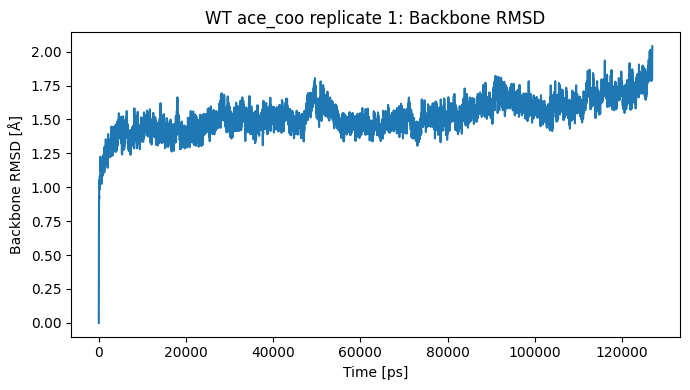

count    6349.000000
mean        1.526243
std         0.127418
min         0.000000
25%         1.446254
50%         1.519526
75%         1.603299
max         2.040344
Name: rmsd_A, dtype: float64


In [23]:
from MDAnalysis.analysis import rms

# Select protein backbone atoms
backbone = u.select_atoms("protein and backbone")

# Calculate backbone RMSD relative to first frame
rmsd_analysis = rms.RMSD(
    backbone,
    backbone,
    select="backbone",
    ref_frame=0
).run()

# Convert RMSD output to DataFrame
rmsd_df = pd.DataFrame(
    rmsd_analysis.results.rmsd,
    columns=["frame", "time_ps", "rmsd_A"]
)

# Save RMSD data
rmsd_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_backbone_rmsd.csv",
    index=False
)

print(rmsd_df.head())

# Plot RMSD trajectory
plt.figure(figsize=(7, 4))

plt.plot(
    rmsd_df["time_ps"],
    rmsd_df["rmsd_A"]
)

plt.xlabel("Time [ps]")
plt.ylabel("Backbone RMSD [Å]")
plt.title("WT ace_coo replicate 1: Backbone RMSD")

plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_backbone_rmsd.png",
    dpi=300
)

plt.show()

# Summary statistics
rmsd_summary = rmsd_df["rmsd_A"].describe()

print(rmsd_summary)

## Residue-level flexibility analysis (RMSF)

Root mean square fluctuation (RMSF) analysis was performed in order to quantify residue-level backbone flexibility throughout the trajectory.

Only protein Cα atoms were included in the analysis to obtain residue-resolved flexibility profiles.

Prior to RMSF calculation, the trajectory was structurally aligned to the first simulation frame in order to remove global rotational and translational motion.

Initial RMSF calculations without structural alignment produced unrealistically large fluctuations across nearly all residues, indicating that global system motion dominated the signal.

The aligned trajectory was therefore used for all subsequent RMSF analyses.

/rwthfs/rz/cluster/home/dwp46550/ba_nylon/envs/ba_nylc/lib64/python3.9/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


   resid resname chainID    rmsf_A
0     19     ASP       A  6.352635
1     20     PRO       A  4.852071
2     21     ALA       A  3.534965
3     22     PRO       A  1.913999
4     23     ARG       A  0.814298


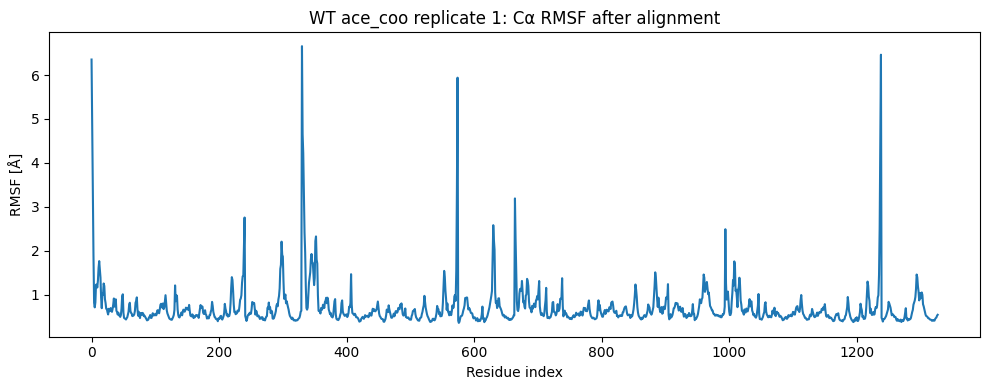

     resid resname chainID    rmsf_A
80      99     ASP       A  0.585335
115    134     PHE       A  0.859369
241    267     THR       B  0.517434
278    304     ASP       B  0.820770
280    306     ASP       B  0.715020
282    308     ASP       B  0.634079
304    330     ARG       B  1.003528



 Top 10 most flexible residues
    residue    rmsf_A
0   C16_ILE  6.656738
1  G260_PRO  6.462169
2   A19_ASP  6.352635
3  C260_PRO  5.939485
4   A20_PRO  4.852071
5   C17_ALA  4.655839
6  G259_PRO  4.386770
7   C18_VAL  4.222500
8   A21_ALA  3.534965
9  C259_PRO  3.403901


In [28]:
from MDAnalysis.analysis import align
from MDAnalysis.analysis.rms import RMSF

# Reload universe to start from unmodified coordinates
u = mda.Universe(
    row["chains_pdb_path"],
    row["xtc_path"]
)

# Select protein Cα atoms
ca_atoms = u.select_atoms("protein and name CA")

# Align all frames to the first frame using Cα atoms
align.AlignTraj(
    u,
    u,
    select="protein and name CA",
    ref_frame=0,
    in_memory=True
).run()

# Re-select Cα atoms after alignment
ca_atoms = u.select_atoms("protein and name CA")

# RMSF calculation after alignment
rmsf_analysis = RMSF(ca_atoms).run()

# Build DataFrame
rmsf_df = pd.DataFrame({
    "resid": ca_atoms.resids,
    "resname": ca_atoms.resnames,
    "chainID": ca_atoms.chainIDs,
    "rmsf_A": rmsf_analysis.results.rmsf
})

# Save results
rmsf_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_rmsf_aligned.csv",
    index=False
)

print(rmsf_df.head())

# Plot
plt.figure(figsize=(10, 4))

plt.plot(
    rmsf_df.index,
    rmsf_df["rmsf_A"]
)

plt.xlabel("Residue index")
plt.ylabel("RMSF [Å]")
plt.title("WT ace_coo replicate 1: Cα RMSF after alignment")

plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_rmsf_aligned.png",
    dpi=300
)

plt.show()

# Inspect functionally important residues
important_sites = [
    ("A", 99),
    ("A", 134),
    ("B", 267),
    ("B", 304),
    ("B", 306),
    ("B", 308),
    ("B", 330),
]

important_rmsf = rmsf_df[
    rmsf_df.apply(
        lambda x: (x["chainID"], x["resid"]) in important_sites,
        axis=1
    )
]

print(important_rmsf)

print("\n")
# Top 10 most flexible residues
print("\n Top 10 most flexible residues")
top_rmsf = (
    rmsf_df
    .sort_values("rmsf_A", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_rmsf["residue"] = (
    top_rmsf["chainID"]
    + top_rmsf["resid"].astype(str)
    + "_"
    + top_rmsf["resname"]
)

print(
    top_rmsf[
        ["residue", "rmsf_A"]
    ]
)

## Catalytic triad geometry analysis

The structural stability of the catalytic triad was analyzed throughout the trajectory by monitoring pairwise distances between the catalytically relevant residues:
- B267 (THR)
- B306 (ASP)
- B308 (ASP)

Cα atom distances were used as robust residue-level geometric descriptors of the catalytic core architecture.

For each trajectory frame:
- the distances between all catalytic residue pairs were calculated
- the resulting distance trajectories were stored in a dataframe
- summary statistics were computed
- temporal distance traces and distance distributions were visualized

This analysis was performed to evaluate whether the catalytic center remains geometrically stable during the simulation.

Stable distance distributions with low variance would indicate preservation of the catalytic architecture, whereas large fluctuations or multimodal distributions could suggest conformational rearrangements of the active site.

   frame  time_ps                pair  distance_A  valid
0      0      0.0  B267_THR__B306_ASP    4.364078   True
1      0      0.0  B267_THR__B308_ASP    5.097637   True
2      0      0.0  B306_ASP__B308_ASP    5.767171   True
3      1     20.0  B267_THR__B306_ASP    4.301758   True
4      1     20.0  B267_THR__B308_ASP    4.686249   True
                 pair      mean       std       min       max
0  B267_THR__B306_ASP  5.030039  0.222682  3.874249  6.018383
1  B267_THR__B308_ASP  5.034682  0.179971  4.255159  5.656697
2  B306_ASP__B308_ASP  5.916936  0.215981  5.076031  6.597563


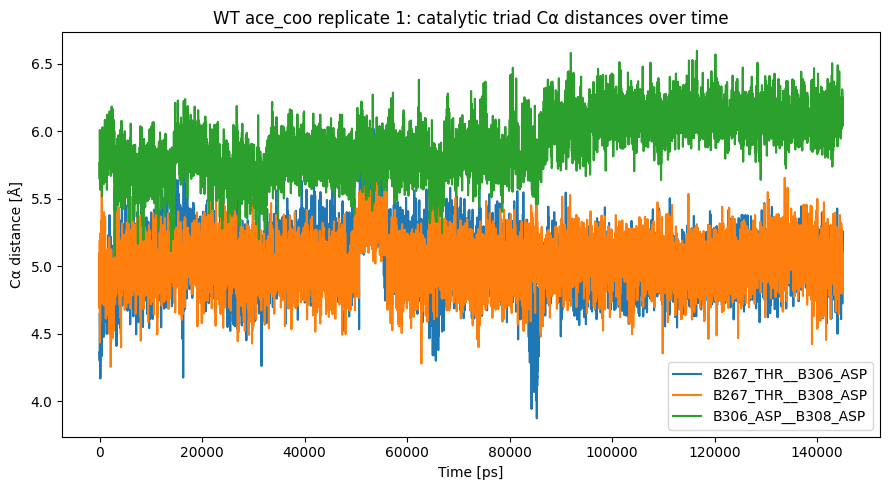

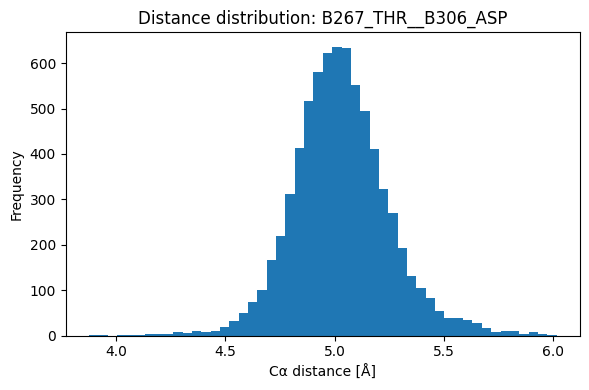

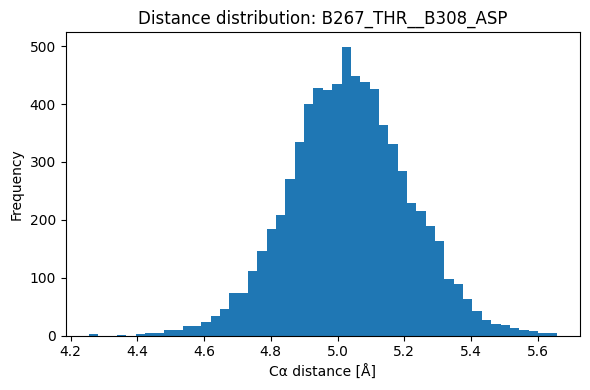

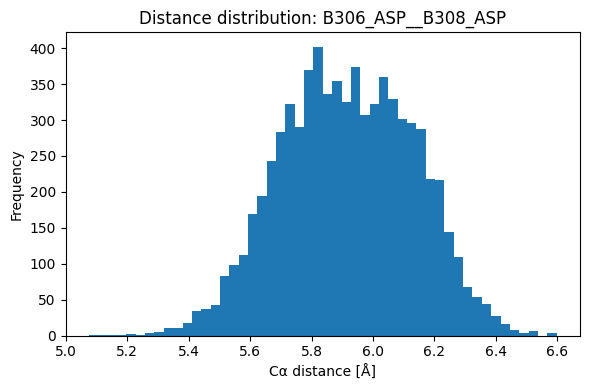

In [29]:
from MDAnalysis.lib.distances import calc_bonds
## Catalytic triad geometry over time

triad_ca_pairs = [
    ("B267_THR", "B306_ASP", "protein and chainID B and resid 267 and name CA", "protein and chainID B and resid 306 and name CA"),
    ("B267_THR", "B308_ASP", "protein and chainID B and resid 267 and name CA", "protein and chainID B and resid 308 and name CA"),
    ("B306_ASP", "B308_ASP", "protein and chainID B and resid 306 and name CA", "protein and chainID B and resid 308 and name CA"),
]

records = []

for ts in u.trajectory:
    for site1, site2, sel1_str, sel2_str in triad_ca_pairs:
        sel1 = u.select_atoms(sel1_str)
        sel2 = u.select_atoms(sel2_str)

        if sel1.n_atoms != 1 or sel2.n_atoms != 1:
            records.append({
                "frame": ts.frame,
                "time_ps": ts.time,
                "pair": f"{site1}__{site2}",
                "distance_A": np.nan,
                "valid": False
            })
            continue

        distance = calc_bonds(
            sel1.positions,
            sel2.positions
        )[0]

        records.append({
            "frame": ts.frame,
            "time_ps": ts.time,
            "pair": f"{site1}__{site2}",
            "distance_A": distance,
            "valid": True
        })

triad_ca_df = pd.DataFrame(records)

triad_ca_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_triad_CA_distances.csv",
    index=False
)

print(triad_ca_df.head())


#Summary

triad_ca_summary = (
    triad_ca_df
    .groupby("pair")["distance_A"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

print(triad_ca_summary)

#Plot 

plt.figure(figsize=(9, 5))

for pair, sub in triad_ca_df.groupby("pair"):
    plt.plot(
        sub["time_ps"],
        sub["distance_A"],
        label=pair
    )

plt.xlabel("Time [ps]")
plt.ylabel("Cα distance [Å]")
plt.title("WT ace_coo replicate 1: catalytic triad Cα distances over time")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_triad_CA_distances.png",
    dpi=300
)

plt.show()

#Plot Histogramms

for pair, sub in triad_ca_df.groupby("pair"):
    plt.figure(figsize=(6, 4))

    plt.hist(
        sub["distance_A"].dropna(),
        bins=50
    )

    plt.xlabel("Cα distance [Å]")
    plt.ylabel("Frequency")
    plt.title(f"Distance distribution: {pair}")

    plt.tight_layout()

    filename = pair.replace("__", "_").replace(" ", "_")
    plt.savefig(
        FIGURES / f"WT_ace_coo_rep1_{filename}_distance_hist.png",
        dpi=300
    )

    plt.show()

## Residue-wise substrate contact frequency analysis

Residue-wise contact frequencies between the protein and the ligand were calculated to identify residues that interact persistently with the docked PA6 tetramer substrate.

A residue was considered to be in contact with the ligand in a given frame if any atom of the residue was within 2.5 Å of any ligand atom.

This cutoff follows the contact definition used in the KnowVolution study, where residues with at least 50% contact frequency were considered relevant for enzyme-substrate interaction analysis.

The resulting contact frequencies are used to identify:
- persistent substrate-contacting residues
- active-site residues involved in substrate positioning
- candidate residues for pocket engineering

Ligand atoms: 83
Ligand residues:
356 UNL1 83


    chainID  resid resname  n_contact_frames  n_total_frames  \
128       A    146     TYR              7251            7251   
73        A     91     ALA              7137            7251   
456       C    139     LEU              6648            7251   
171       A    189     LYS              6197            7251   
243       B    267     THR              6172            7251   
131       A    149     SER              5730            7251   
201       A    219     ASN              5466            7251   
451       C    134     PHE              5206            7251   
126       A    144     VAL              5104            7251   
75        A     93     GLY              4334            7251   
174       A    192     TRP              4043            7251   
454       C    137     LEU              3508            7251   
415       C     98     TYR              3506            7251   
10        A     28     PRO              3200            7251   
12        A     30     PHE              

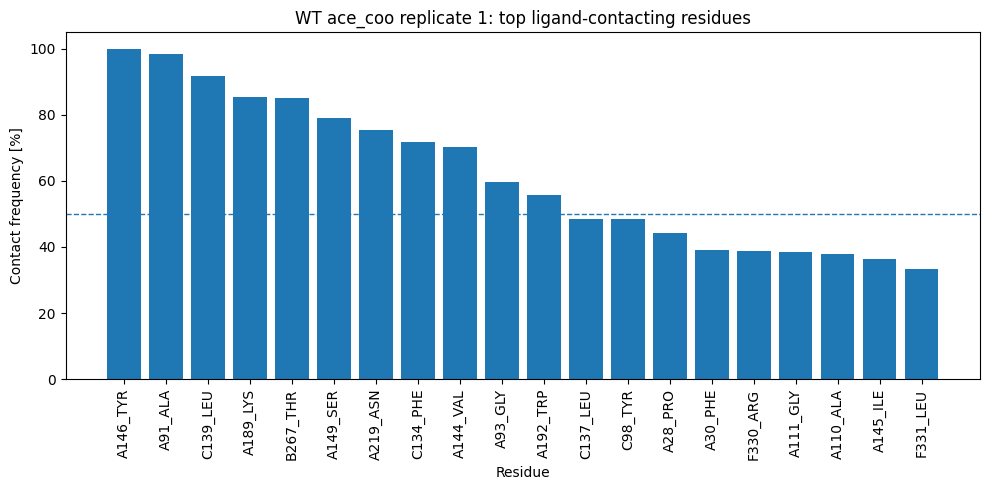

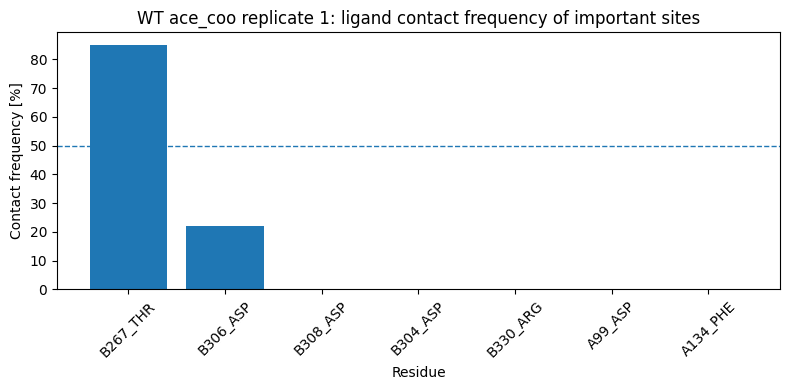

chainID
A    22
B     4
C    11
E     7
F     6
dtype: int64


In [38]:
from MDAnalysis.lib.distances import distance_array
## Identify ligand atoms

excluded_resnames = [
    "SOL", "WAT", "HOH",
    "NA", "CL", "K", "MG", "CA", #?
    "SOD", "CLA"
]

excluded_string = " ".join(excluded_resnames)

ligand = u.select_atoms(
    f"not protein and not resname {excluded_string}"
)

print("Ligand atoms:", ligand.n_atoms)
print("Ligand residues:")

for res in ligand.residues:
    print(res.resid, res.resname, len(res.atoms))

## Calculate residue-wise ligand contact frequencies

contact_cutoff_A = 2.5

protein_residues = u.select_atoms("protein").residues

contact_counts = {
    (res.segid, res.resid, res.resname): 0
    for res in protein_residues
}

n_frames = len(u.trajectory)

for ts in u.trajectory:
    ligand_positions = ligand.positions

    for res in protein_residues:
        res_atoms = res.atoms

        distances = distance_array(
            res_atoms.positions,
            ligand_positions
        )

        has_contact = np.any(distances <= contact_cutoff_A)

        if has_contact:
            key = (res.segid, res.resid, res.resname)
            contact_counts[key] += 1

contact_records = []

for (chainID, resid, resname), count in contact_counts.items():
    contact_records.append({
        "chainID": chainID,
        "resid": resid,
        "resname": resname,
        "n_contact_frames": count,
        "n_total_frames": n_frames,
        "contact_frequency": count / n_frames,
        "contact_frequency_percent": 100 * count / n_frames
    })

contact_frequency_df = pd.DataFrame(contact_records)

contact_frequency_df = contact_frequency_df.sort_values(
    "contact_frequency",
    ascending=False
)

contact_frequency_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_contact_frequency_by_residue.csv",
    index=False
)

print(contact_frequency_df.head(20))

high_contact_residues = contact_frequency_df[
    contact_frequency_df["contact_frequency"] >= 0.50
].copy()

print(high_contact_residues.head(20))

important_sites = [
    ("A", 99),
    ("A", 134),
    ("B", 267),
    ("B", 304),
    ("B", 306),
    ("B", 308),
    ("B", 330),
]

important_contact_frequency = contact_frequency_df[
    contact_frequency_df.apply(
        lambda x: (x["chainID"], x["resid"]) in important_sites,
        axis=1
    )
].copy()

print(important_contact_frequency)

top_contacts = contact_frequency_df.head(20).copy()

top_contacts["residue"] = (
    top_contacts["chainID"].astype(str)
    + top_contacts["resid"].astype(str)
    + "_"
    + top_contacts["resname"].astype(str)
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_contacts["residue"],
    top_contacts["contact_frequency_percent"]
)

plt.axhline(
    50,
    linestyle="--",
    linewidth=1
)

plt.xticks(rotation=90)
plt.ylabel("Contact frequency [%]")
plt.xlabel("Residue")
plt.title("WT ace_coo replicate 1: top ligand-contacting residues")

plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_top20_ligand_contact_residues.png",
    dpi=300
)

plt.show()

#plot for important residues
important_plot_df = important_contact_frequency.copy()

important_plot_df["residue"] = (
    important_plot_df["chainID"].astype(str)
    + important_plot_df["resid"].astype(str)
    + "_"
    + important_plot_df["resname"].astype(str)
)

plt.figure(figsize=(8, 4))

plt.bar(
    important_plot_df["residue"],
    important_plot_df["contact_frequency_percent"]
)

plt.axhline(
    50,
    linestyle="--",
    linewidth=1
)

plt.xticks(rotation=45)
plt.ylabel("Contact frequency [%]")
plt.xlabel("Residue")
plt.title("WT ace_coo replicate 1: ligand contact frequency of important sites")

plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_important_sites_ligand_contact_frequency.png",
    dpi=300
)

plt.show()

#ligand associated chains

top_contacts = contact_frequency_df.head(50)

print(top_contacts.groupby("chainID").size())

## Identification of ligand-associated active-site copy

Because the enzyme complex is multimeric and contains repeated catalytic subunits, the same catalytic residue numbers occur in multiple chains.

Therefore, the ligand-associated active-site copy was identified by calculating the minimum distance between each candidate catalytic triad and the ligand over the trajectory.

This avoids assuming that a predefined chain contains the functionally relevant active site in every simulation.

In [40]:
candidate_triads = []

for chain in ["B", "D", "F", "H"]:
    for resid in [267, 306, 308]:
        sel = u.select_atoms(f"protein and chainID {chain} and resid {resid}")
        candidate_triads.append({
            "chainID": chain,
            "resid": resid,
            "n_atoms": sel.n_atoms,
            "resname": ",".join(sorted(set(sel.residues.resnames))) if sel.n_atoms > 0 else "missing"
        })

candidate_triads_df = pd.DataFrame(candidate_triads)
print(candidate_triads_df)

triad_chains = ["B", "D", "F", "H"]

records = []

for chain in triad_chains:
    triad_atoms = u.select_atoms(
        f"protein and chainID {chain} and resid 267 306 308"
    )
    
    min_distances = []

    for ts in u.trajectory:
        distances = distance_array(
            triad_atoms.positions,
            ligand.positions
        )
        min_distances.append(distances.min())

    records.append({
        "triad_chain": chain,
        "mean_min_distance_to_ligand_A": np.mean(min_distances),
        "min_distance_to_ligand_A": np.min(min_distances),
        "contact_frequency_2_5A": np.mean(np.array(min_distances) <= 2.5)
    })

triad_ligand_proximity_df = pd.DataFrame(records)
triad_ligand_proximity_df.sort_values("mean_min_distance_to_ligand_A")

   chainID  resid  n_atoms resname
0        B    267       15     THR
1        B    306       12     ASP
2        B    308       12     ASP
3        D    267       15     THR
4        D    306       12     ASP
5        D    308       12     ASP
6        F    267       15     THR
7        F    306       12     ASP
8        F    308       12     ASP
9        H    267       15     THR
10       H    306       12     ASP
11       H    308       12     ASP


,triad_chain,mean_min_distance_to_ligand_A,min_distance_to_ligand_A,contact_frequency_2_5A
0,B,2.302437,1.629050,0.886498
1,D,19.352431,16.745634,0.000000
2,F,25.842828,23.900536,0.000000
3,H,26.988113,23.692769,0.000000


## Identification of the ligand-associated catalytic triad

The multimeric enzyme complex contains four structurally equivalent catalytic triads located in chains B, D, F and H.

To identify the functionally relevant active-site copy in the current simulation, the minimum distance between each catalytic triad and the ligand was calculated throughout the trajectory.

Only the catalytic triad in chain B showed persistent proximity to the ligand:
- mean minimum distance: 2.30 Å
- minimum observed distance: 1.63 Å
- contact frequency within 2.5 Å: 88.6%

In contrast, the catalytic triads in chains D, F and H remained distant from the ligand throughout the simulation.

This indicates that only the B-chain catalytic center is functionally engaged with the ligand in the analyzed trajectory.

## R330 and D99R interaction analysis

Electrostatic interactions involving R330 and D99R were analyzed because these residues may stabilize charged substrate termini and thereby influence substrate binding, hydrolysis, and epistatic effects.

For R330, the minimum distance between the positively charged sidechain atoms and the ligand was monitored over time.

Where ligand carboxylate atoms could be identified, a salt-bridge proxy was calculated using the minimum distance between R330 guanidinium atoms and ligand carboxylate oxygens.

For D99R-containing variants, analogous distances were calculated for:
- D99R to ligand
- D99R to D304

These analyses provide mechanistic descriptors of persistent electrostatic interactions that may explain activity-enhancing or activity-reducing effects.

Ligand atoms: 83
Ligand residue names: ['UNL1']
Ligand atom names: ['C1', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C2', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'H1', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H2', 'H20', 'H21', 'H22', 'H23', 'H24', 'H25', 'H26', 'H27', 'H28', 'H29', 'H3', 'H30', 'H31', 'H32', 'H33', 'H34', 'H35', 'H36', 'H37', 'H38', 'H39', 'H4', 'H40', 'H41', 'H42', 'H43', 'H44', 'H45', 'H46', 'H47', 'H5', 'H6', 'H7', 'H8', 'H9', 'N1', 'N2', 'N3', 'N4', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6']
O1 nearest carbons: [('C6', 1.27), ('C5', 2.47), ('C7', 2.91)]
O2 nearest carbons: [('C12', 1.17), ('C11', 2.32), ('C13', 2.76)]
O3 nearest carbons: [('C18', 1.26), ('C17', 2.34), ('C16', 3.74)]
O4 nearest carbons: [('C18', 1.26), ('C17', 2.4), ('C16', 2.87)]
O5 nearest carbons: [('C19', 1.26), ('C20', 2.41), ('C1', 2.91)]
O6 nearest carbons: [('C25', 1.22), ('C26', 2.35), ('C

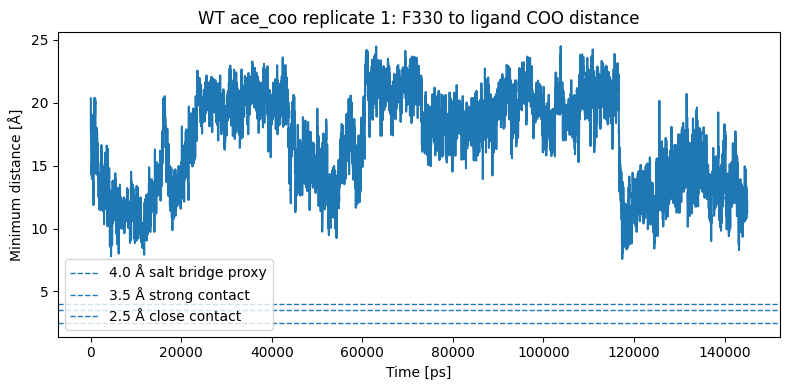

In [45]:
from MDAnalysis.lib.distances import distance_array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select ligand
ligand = u.select_atoms("resname UNL1")

print("Ligand atoms:", ligand.n_atoms)
print("Ligand residue names:", sorted(set(ligand.resnames)))
print("Ligand atom names:", sorted(set(ligand.names)))
# Inspect ligand oxygen atoms and their nearest carbon atoms
# This is used to identify likely carboxylate oxygens.

oxygen_atoms = ligand.select_atoms("name O*")
carbon_atoms = ligand.select_atoms("name C*")

for o in oxygen_atoms:
    distances = distance_array(
        o.position.reshape(1, 3),
        carbon_atoms.positions
    )[0]

    nearest_idx = np.argsort(distances)[:3]

    print(
        o.name,
        "nearest carbons:",
        [(carbon_atoms[i].name, round(distances[i], 2)) for i in nearest_idx]
    )
# O3 and O4 share the same nearest carbon atom C18.
# Therefore, they are treated as the likely terminal carboxylate oxygens.

ligand_coo = ligand.select_atoms("name O3 O4")

print("Selected COO atoms:", ligand_coo.n_atoms, ligand_coo.names)
# Analyze R330-COO distance for the B-chain active-site copy

r330_positive_atoms = u.select_atoms(
    "protein and chainID B and resid 330 and name NE NH1 NH2"
)

print("B330 positive atoms:", r330_positive_atoms.n_atoms, r330_positive_atoms.names)

records = []

for ts in u.trajectory:
    distances = distance_array(
        r330_positive_atoms.positions,
        ligand_coo.positions
    )

    min_distance = distances.min()

    records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "min_distance_R330_COO_A": min_distance,
        "salt_bridge_proxy_4A": min_distance <= 4.0,
        "strong_contact_3_5A": min_distance <= 3.5,
        "hbond_like_2_5A": min_distance <= 2.5,
    })

r330_coo_df = pd.DataFrame(records)

r330_coo_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_B330_COO_distance.csv",
    index=False
)

print("B330-COO ≤4.0 Å:", r330_coo_df["salt_bridge_proxy_4A"].mean())
print("B330-COO ≤3.5 Å:", r330_coo_df["strong_contact_3_5A"].mean())
print("B330-COO ≤2.5 Å:", r330_coo_df["hbond_like_2_5A"].mean())
# Analyze R330-COO distances across all R330-containing small chains

r330_chains = ["B", "D", "F", "H"]

records = []

for chain in r330_chains:
    r330_positive_atoms = u.select_atoms(
        f"protein and chainID {chain} and resid 330 and name NE NH1 NH2"
    )

    if r330_positive_atoms.n_atoms == 0:
        records.append({
            "chainID": chain,
            "n_positive_atoms": 0,
            "mean_min_distance_R330_COO_A": np.nan,
            "min_distance_R330_COO_A": np.nan,
            "contact_freq_4A": np.nan,
            "contact_freq_3_5A": np.nan,
            "contact_freq_2_5A": np.nan,
        })
        continue

    min_distances = []

    for ts in u.trajectory:
        distances = distance_array(
            r330_positive_atoms.positions,
            ligand_coo.positions
        )
        min_distances.append(distances.min())

    min_distances = np.array(min_distances)

    records.append({
        "chainID": chain,
        "n_positive_atoms": r330_positive_atoms.n_atoms,
        "mean_min_distance_R330_COO_A": min_distances.mean(),
        "min_distance_R330_COO_A": min_distances.min(),
        "contact_freq_4A": np.mean(min_distances <= 4.0),
        "contact_freq_3_5A": np.mean(min_distances <= 3.5),
        "contact_freq_2_5A": np.mean(min_distances <= 2.5),
    })

r330_all_chains_coo_df = pd.DataFrame(records)

r330_all_chains_coo_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_all_R330_COO_distance_summary.csv",
    index=False
)

r330_all_chains_coo_df.sort_values("mean_min_distance_R330_COO_A")

r330_coo_df.describe()
# Analyze R330 contacts to the entire ligand across all R330 copies

records = []

for chain in r330_chains:
    r330_sidechain = u.select_atoms(
        f"protein and chainID {chain} and resid 330 and not backbone"
    )

    if r330_sidechain.n_atoms == 0:
        records.append({
            "chainID": chain,
            "n_sidechain_atoms": 0,
            "mean_min_distance_R330_ligand_A": np.nan,
            "min_distance_R330_ligand_A": np.nan,
            "contact_freq_4A": np.nan,
            "contact_freq_3_5A": np.nan,
            "contact_freq_2_5A": np.nan,
        })
        continue

    min_distances = []

    for ts in u.trajectory:
        distances = distance_array(
            r330_sidechain.positions,
            ligand.positions
        )
        min_distances.append(distances.min())

    min_distances = np.array(min_distances)

    records.append({
        "chainID": chain,
        "n_sidechain_atoms": r330_sidechain.n_atoms,
        "mean_min_distance_R330_ligand_A": min_distances.mean(),
        "min_distance_R330_ligand_A": min_distances.min(),
        "contact_freq_4A": np.mean(min_distances <= 4.0),
        "contact_freq_3_5A": np.mean(min_distances <= 3.5),
        "contact_freq_2_5A": np.mean(min_distances <= 2.5),
    })

r330_all_chains_ligand_df = pd.DataFrame(records)

r330_all_chains_ligand_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_all_R330_ligand_distance_summary.csv",
    index=False
)

r330_all_chains_ligand_df.sort_values("mean_min_distance_R330_ligand_A")
# F330 to ligand COO distance

f330_positive_atoms = u.select_atoms(
    "protein and chainID F and resid 330 and name NE NH1 NH2"
)

records = []

for ts in u.trajectory:
    distances = distance_array(
        f330_positive_atoms.positions,
        ligand_coo.positions
    )

    min_distance = distances.min()

    records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "min_distance_F330_COO_A": min_distance,
        "salt_bridge_proxy_4A": min_distance <= 4.0,
        "strong_contact_3_5A": min_distance <= 3.5,
        "hbond_like_2_5A": min_distance <= 2.5,
    })

f330_coo_df = pd.DataFrame(records)

print("F330-COO ≤4.0 Å:", f330_coo_df["salt_bridge_proxy_4A"].mean())
print("F330-COO ≤3.5 Å:", f330_coo_df["strong_contact_3_5A"].mean())
print("F330-COO ≤2.5 Å:", f330_coo_df["hbond_like_2_5A"].mean())

f330_coo_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_F330_COO_distance.csv",
    index=False
)

f330_coo_df.describe()
plt.figure(figsize=(8, 4))

plt.plot(
    f330_coo_df["time_ps"],
    f330_coo_df["min_distance_F330_COO_A"]
)

plt.axhline(4.0, linestyle="--", linewidth=1, label="4.0 Å salt bridge proxy")
plt.axhline(3.5, linestyle="--", linewidth=1, label="3.5 Å strong contact")
plt.axhline(2.5, linestyle="--", linewidth=1, label="2.5 Å close contact")

plt.xlabel("Time [ps]")
plt.ylabel("Minimum distance [Å]")
plt.title("WT ace_coo replicate 1: F330 to ligand COO distance")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_F330_COO_distance.png",
    dpi=300
)

plt.show()

## R330 interaction observation

Neither B330 nor F330 formed close contacts with the assigned ligand carboxylate group O3/O4 in WT / ace_coo / replicate 1.

However, F330 showed persistent proximity to the overall ligand in the previous whole-ligand distance analysis. This indicates that F330 interacts with another region of the substrate rather than the terminal COO⁻ group.

Therefore, R330-mediated ligand interaction is present in this trajectory, but it cannot be interpreted as carboxylate/salt-bridge stabilization based on the current COO assignment.

In [46]:
f330_sidechain = u.select_atoms(
    "protein and chainID F and resid 330 and not backbone"
)

contact_cutoff_A = 4.0

atom_contact_counts = {
    atom.name: 0
    for atom in ligand
}

for ts in u.trajectory:
    distances = distance_array(
        f330_sidechain.positions,
        ligand.positions
    )

    ligand_contact_mask = (distances <= contact_cutoff_A).any(axis=0)

    for atom, has_contact in zip(ligand, ligand_contact_mask):
        if has_contact:
            atom_contact_counts[atom.name] += 1

f330_ligand_atom_contacts = pd.DataFrame([
    {
        "ligand_atom": atom_name,
        "n_contact_frames": count,
        "contact_frequency": count / len(u.trajectory),
        "contact_frequency_percent": 100 * count / len(u.trajectory),
    }
    for atom_name, count in atom_contact_counts.items()
]).sort_values("contact_frequency", ascending=False)

f330_ligand_atom_contacts.head(20)

,ligand_atom,n_contact_frames,contact_frequency,contact_frequency_percent
35,O6,4359,0.601158,60.115846
33,C25,4237,0.584333,58.433320
34,C26,3715,0.512343,51.234313
82,H47,2701,0.372500,37.250034
81,H46,2665,0.367536,36.753551
80,H45,2649,0.365329,36.532892
78,H43,2627,0.362295,36.229486
77,H42,2611,0.360088,36.008826
31,C24,2563,0.353468,35.346849
32,N4,2244,0.309475,30.947456


In [47]:
ligand_o6 = ligand.select_atoms("name O6")

f330_positive_atoms = u.select_atoms(
    "protein and chainID F and resid 330 and name NE NH1 NH2"
)

records = []

for ts in u.trajectory:
    distances = distance_array(
        f330_positive_atoms.positions,
        ligand_o6.positions
    )

    min_distance = distances.min()

    records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "distance_F330_O6_A": min_distance,
        "contact_4A": min_distance <= 4.0,
        "contact_3_5A": min_distance <= 3.5,
        "contact_2_5A": min_distance <= 2.5,
    })

f330_o6_df = pd.DataFrame(records)

print("F330-O6 ≤4 Å:", f330_o6_df["contact_4A"].mean())
print("F330-O6 ≤3.5 Å:", f330_o6_df["contact_3_5A"].mean())
print("F330-O6 ≤2.5 Å:", f330_o6_df["contact_2_5A"].mean())

f330_o6_df.describe()

F330-O6 ≤4 Å: 0.12646531512894774
F330-O6 ≤3.5 Å: 0.0671631499103572
F330-O6 ≤2.5 Å: 0.0


,frame,time_ps,distance_F330_O6_A
count,7251.000000,7251.000000,7251.000000
mean,3625.000000,72500.000000,6.067842
std,2093.327734,41866.554671,2.164800
min,0.000000,0.000000,2.556181
25%,1812.500000,36250.000000,4.735213
50%,3625.000000,72500.000000,5.626777
75%,5437.500000,108750.000000,6.708303
max,7250.000000,145000.000000,16.230849


In [48]:
f330_contact_region = ligand.select_atoms("name O6 C25 C26 N4")

f330_sidechain = u.select_atoms(
    "protein and chainID F and resid 330 and not backbone"
)

records = []

for ts in u.trajectory:
    distances = distance_array(
        f330_sidechain.positions,
        f330_contact_region.positions
    )

    min_distance = distances.min()

    records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "min_distance_F330_contact_region_A": min_distance,
        "contact_4A": min_distance <= 4.0,
        "contact_3_5A": min_distance <= 3.5,
        "contact_2_5A": min_distance <= 2.5,
    })

f330_region_df = pd.DataFrame(records)

print("F330-region ≤4 Å:", f330_region_df["contact_4A"].mean())
print("F330-region ≤3.5 Å:", f330_region_df["contact_3_5A"].mean())
print("F330-region ≤2.5 Å:", f330_region_df["contact_2_5A"].mean())

f330_region_df.describe()

F330-region ≤4 Å: 0.6949386291545994
F330-region ≤3.5 Å: 0.6183974624189766
F330-region ≤2.5 Å: 0.14287684457316233


,frame,time_ps,min_distance_F330_contact_region_A
count,7251.000000,7251.000000,7251.000000
mean,3625.000000,72500.000000,3.842846
std,2093.327734,41866.554671,1.804555
min,0.000000,0.000000,1.634653
25%,1812.500000,36250.000000,2.621919
50%,3625.000000,72500.000000,3.019572
75%,5437.500000,108750.000000,4.491570
max,7250.000000,145000.000000,11.682676


## F330 ligand interaction analysis

Although F330 did not form persistent close contacts with the assigned terminal carboxylate oxygens O3/O4, region-based analysis revealed strong and persistent interactions with a ligand region containing O6, C25, C26 and N4.

The interaction frequencies were:
- 69.5% within 4.0 Å
- 61.8% within 3.5 Å
- 14.3% within 2.5 Å

The median minimum distance was approximately 3.0 Å, indicating stable proximity between F330 and this ligand region throughout substantial parts of the trajectory.

These results suggest that R330-mediated substrate stabilization in this trajectory is not dominated by one persistent terminal salt bridge, but rather by distributed interactions with a terminal amide/carbonyl-containing substrate region.

In [50]:
from MDAnalysis.lib.distances import distance_array, calc_bonds, calc_dihedrals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

res134 = u.select_atoms("protein and chainID A and resid 134")

print("A134 atoms:", res134.n_atoms)
print("A134 resname:", sorted(set(res134.residues.resnames)))
print("A134 atom names:", sorted(set(res134.names)))

def get_atom_position(u, selection):
    atoms = u.select_atoms(selection)
    if atoms.n_atoms != 1:
        return None
    return atoms.positions[0]

resname_134 = list(set(res134.residues.resnames))[0]

if resname_134 == "PHE":
    chi1_atoms = ["N", "CA", "CB", "CG"]
    chi2_atoms = ["CA", "CB", "CG", "CD1"]
elif resname_134 == "TRP":
    chi1_atoms = ["N", "CA", "CB", "CG"]
    chi2_atoms = ["CA", "CB", "CG", "CD1"]
else:
    raise ValueError(
        f"Residue A134 is {resname_134}; chi definitions need manual adjustment."
    )

records = []

for ts in u.trajectory:
    atom_positions_chi1 = []
    atom_positions_chi2 = []

    for atom_name in chi1_atoms:
        pos = get_atom_position(
            u,
            f"protein and chainID A and resid 134 and name {atom_name}"
        )
        atom_positions_chi1.append(pos)

    for atom_name in chi2_atoms:
        pos = get_atom_position(
            u,
            f"protein and chainID A and resid 134 and name {atom_name}"
        )
        atom_positions_chi2.append(pos)

    if any(pos is None for pos in atom_positions_chi1):
        chi1_deg = np.nan
    else:
        chi1_rad = calc_dihedrals(
            atom_positions_chi1[0],
            atom_positions_chi1[1],
            atom_positions_chi1[2],
            atom_positions_chi1[3]
        )
        chi1_deg = np.degrees(chi1_rad)

    if any(pos is None for pos in atom_positions_chi2):
        chi2_deg = np.nan
    else:
        chi2_rad = calc_dihedrals(
            atom_positions_chi2[0],
            atom_positions_chi2[1],
            atom_positions_chi2[2],
            atom_positions_chi2[3]
        )
        chi2_deg = np.degrees(chi2_rad)

    records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "chainID": "A",
        "resid": 134,
        "resname": resname_134,
        "chi1_deg": chi1_deg,
        "chi2_deg": chi2_deg,
    })

f134_chi_df = pd.DataFrame(records)

f134_chi_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_A134_chi_angles.csv",
    index=False
)

print(f134_chi_df.head())

A134 atoms: 20
A134 resname: ['PHE']
A134 atom names: ['C', 'CA', 'CB', 'CD1', 'CD2', 'CE1', 'CE2', 'CG', 'CZ', 'HA', 'HB1', 'HB2', 'HD1', 'HD2', 'HE1', 'HE2', 'HN', 'HZ', 'N', 'O']


   frame  time_ps chainID  resid resname    chi1_deg    chi2_deg
0      0      0.0       A    134     PHE -163.320160 -108.830643
1      1     20.0       A    134     PHE -176.045907 -125.739271
2      2     40.0       A    134     PHE -173.380121 -125.049955
3      3     60.0       A    134     PHE -160.558068 -134.573136
4      4     80.0       A    134     PHE -178.366142 -104.147327


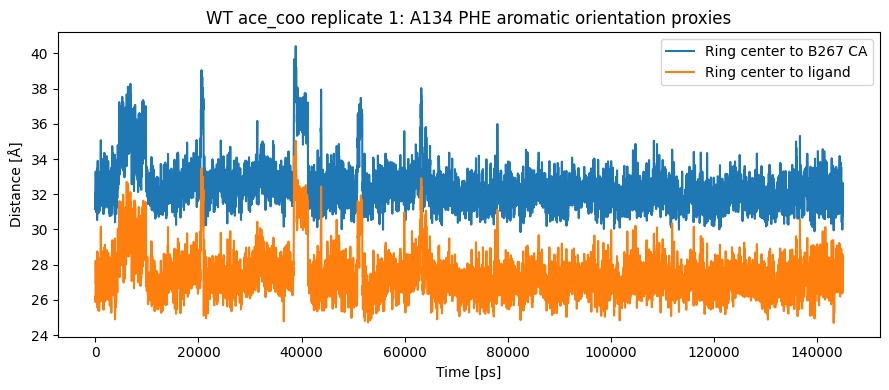

In [51]:
def aromatic_ring_center(u, chain="A", resid=134):
    res = u.select_atoms(f"protein and chainID {chain} and resid {resid}")
    resnames = set(res.residues.resnames)

    if "PHE" in resnames:
        ring = u.select_atoms(
            f"protein and chainID {chain} and resid {resid} and name CG CD1 CD2 CE1 CE2 CZ"
        )
    elif "TRP" in resnames:
        ring = u.select_atoms(
            f"protein and chainID {chain} and resid {resid} and name CG CD1 CD2 NE1 CE2 CE3 CZ2 CZ3 CH2"
        )
    else:
        return None

    if ring.n_atoms == 0:
        return None

    return ring.center_of_geometry()

# Distance of A134 aromatic ring to catalytic T267 and ligand

t267_ca = u.select_atoms("protein and chainID B and resid 267 and name CA")
ligand = u.select_atoms("resname UNL1")

records = []

for ts in u.trajectory:
    ring_center = aromatic_ring_center(u, chain="A", resid=134)

    if ring_center is None or t267_ca.n_atoms != 1 or ligand.n_atoms == 0:
        dist_ring_t267 = np.nan
        dist_ring_ligand = np.nan
    else:
        dist_ring_t267 = np.linalg.norm(
            ring_center - t267_ca.positions[0]
        )

        dist_ring_ligand = distance_array(
            ring_center.reshape(1, 3),
            ligand.positions
        ).min()

    records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "resname": resname_134,
        "ring_center_to_B267_CA_A": dist_ring_t267,
        "ring_center_to_ligand_min_A": dist_ring_ligand,
    })

f134_orientation_df = pd.DataFrame(records)

f134_orientation_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_A134_aromatic_orientation.csv",
    index=False
)

f134_orientation_df.describe()

plt.figure(figsize=(9, 4))

plt.plot(
    f134_orientation_df["time_ps"],
    f134_orientation_df["ring_center_to_B267_CA_A"],
    label="Ring center to B267 CA"
)

plt.plot(
    f134_orientation_df["time_ps"],
    f134_orientation_df["ring_center_to_ligand_min_A"],
    label="Ring center to ligand"
)

plt.xlabel("Time [ps]")
plt.ylabel("Distance [Å]")
plt.title(f"WT ace_coo replicate 1: A134 {resname_134} aromatic orientation proxies")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_A134_aromatic_orientation_distances.png",
    dpi=300
)

plt.show()

In [52]:
ligand_hetero = ligand.select_atoms("name O* N*")

records = []

for ts in u.trajectory:
    ring_center = aromatic_ring_center(u, chain="A", resid=134)

    if ring_center is None or ligand_hetero.n_atoms == 0:
        min_dist = np.nan
    else:
        min_dist = distance_array(
            ring_center.reshape(1, 3),
            ligand_hetero.positions
        ).min()

    records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "min_distance_A134_ring_to_ligand_ON_A": min_dist,
        "contact_4A": min_dist <= 4.0 if not np.isnan(min_dist) else False,
        "contact_3_5A": min_dist <= 3.5 if not np.isnan(min_dist) else False,
    })

f134_ligand_hetero_df = pd.DataFrame(records)

f134_ligand_hetero_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_A134_ring_to_ligand_heteroatoms.csv",
    index=False
)

print("A134 ring to ligand O/N ≤4 Å:", f134_ligand_hetero_df["contact_4A"].mean())
print("A134 ring to ligand O/N ≤3.5 Å:", f134_ligand_hetero_df["contact_3_5A"].mean())

f134_ligand_hetero_df.describe()

A134 ring to ligand O/N ≤4 Å: 0.0
A134 ring to ligand O/N ≤3.5 Å: 0.0


,frame,time_ps,min_distance_A134_ring_to_ligand_ON_A
count,7251.000000,7251.000000,7251.000000
mean,3625.000000,72500.000000,28.957753
std,2093.327734,41866.554671,1.355213
min,0.000000,0.000000,25.594083
25%,1812.500000,36250.000000,28.119384
50%,3625.000000,72500.000000,28.738806
75%,5437.500000,108750.000000,29.455860
max,7250.000000,145000.000000,36.097353


In [53]:
# W134 indole NH interaction analysis
# Only applicable if A134 is TRP

if resname_134 == "TRP":
    w134_ne1 = u.select_atoms(
        "protein and chainID A and resid 134 and name NE1"
    )

    ligand_acceptors = ligand.select_atoms("name O* N*")

    records = []

    for ts in u.trajectory:
        distances = distance_array(
            w134_ne1.positions,
            ligand_acceptors.positions
        )

        min_distance = distances.min()

        records.append({
            "frame": ts.frame,
            "time_ps": ts.time,
            "min_distance_W134_NE1_ligand_acceptor_A": min_distance,
            "hbond_proxy_3_5A": min_distance <= 3.5,
            "close_contact_2_5A": min_distance <= 2.5,
        })

    w134_hbond_df = pd.DataFrame(records)

    w134_hbond_df.to_csv(
        RESULTS / "W134_NE1_ligand_hbond_proxy.csv",
        index=False
    )

    print("W134 NE1 to ligand acceptor ≤3.5 Å:", w134_hbond_df["hbond_proxy_3_5A"].mean())
    print("W134 NE1 to ligand acceptor ≤2.5 Å:", w134_hbond_df["close_contact_2_5A"].mean())

    display(w134_hbond_df.describe())

else:
    print(f"A134 is {resname_134}, not TRP. W134 indole-NH analysis skipped.")

A134 is PHE, not TRP. W134 indole-NH analysis skipped.


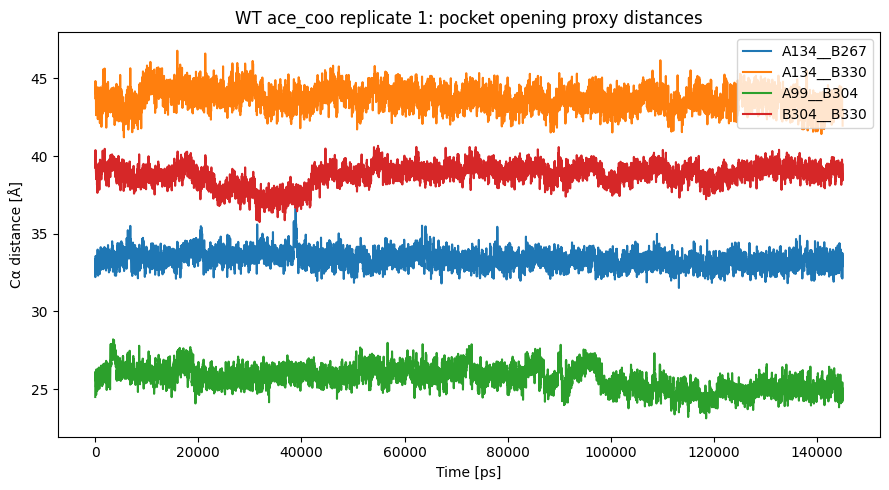

In [54]:
pocket_pairs = [
    ("A134", "B330", "protein and chainID A and resid 134 and name CA", "protein and chainID B and resid 330 and name CA"),
    ("A99", "B304", "protein and chainID A and resid 99 and name CA", "protein and chainID B and resid 304 and name CA"),
    ("A134", "B267", "protein and chainID A and resid 134 and name CA", "protein and chainID B and resid 267 and name CA"),
    ("B304", "B330", "protein and chainID B and resid 304 and name CA", "protein and chainID B and resid 330 and name CA"),
]

records = []

for ts in u.trajectory:
    for site1, site2, sel1_str, sel2_str in pocket_pairs:
        sel1 = u.select_atoms(sel1_str)
        sel2 = u.select_atoms(sel2_str)

        if sel1.n_atoms != 1 or sel2.n_atoms != 1:
            distance = np.nan
            valid = False
        else:
            distance = calc_bonds(
                sel1.positions,
                sel2.positions
            )[0]
            valid = True

        records.append({
            "frame": ts.frame,
            "time_ps": ts.time,
            "pair": f"{site1}__{site2}",
            "distance_A": distance,
            "valid": valid,
        })

pocket_opening_df = pd.DataFrame(records)

pocket_opening_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_pocket_opening_CA_distances.csv",
    index=False
)

pocket_opening_summary = (
    pocket_opening_df
    .groupby("pair")["distance_A"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

pocket_opening_summary

plt.figure(figsize=(9, 5))

for pair, sub in pocket_opening_df.groupby("pair"):
    plt.plot(
        sub["time_ps"],
        sub["distance_A"],
        label=pair
    )

plt.xlabel("Time [ps]")
plt.ylabel("Cα distance [Å]")
plt.title("WT ace_coo replicate 1: pocket opening proxy distances")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_pocket_opening_CA_distances.png",
    dpi=300
)

plt.show()

Protein atoms: 19322
Pocket atoms: 230
Pocket residues:
A 91 ALA
A 98 TYR
A 99 ASP
A 134 PHE
A 137 LEU
A 139 LEU
A 144 VAL
A 146 TYR
B 267 THR
B 304 ASP
B 305 MET
B 306 ASP
B 308 ASP
B 330 ARG
Pocket atom positions in protein AtomGroup: 230


/rwthfs/rz/cluster/home/dwp46550/ba_nylon/envs/ba_nylc/lib64/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'N

atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'NME  N  ' unknown, guessing element is ' N', and radius 1.550 A
FreeSASA: warning: atom 'NME  CH3' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unknown, guessing element is ' C', and radius 1.700 A
FreeSASA: warning: atom 'ILE  CD ' unkno

   frame  time_ps  total_protein_sasa_A2  pocket_sasa_A2
0      0      0.0           40307.278658      938.725163
1    100   2000.0           43795.185458      968.692350
2    200   4000.0           44196.641859      958.831399
3    300   6000.0           44342.178422      994.489331
4    400   8000.0           43956.186174      932.772605


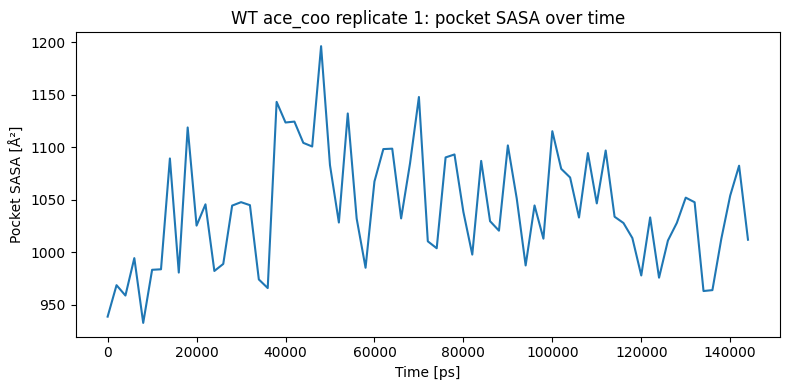

       total_protein_sasa_A2  pocket_sasa_A2
count              73.000000       73.000000
mean            44586.884513     1041.791331
std               724.649853       55.435562
min             40307.278658      932.772605
25%             44269.808695      997.849578
50%             44580.179197     1033.911100
75%             44942.817052     1087.090047
max             45969.963719     1196.402525


In [59]:
import freesasa
import tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TMP = RESULTS / "tmp_freesasa"
TMP.mkdir(parents=True, exist_ok=True)
# Define pocket selection

pocket_selection = (
    "protein and ("
    "(chainID A and resid 91 98 99 134 137 139 144 146) or "
    "(chainID B and resid 267 304 305 306 308 330)"
    ")"
)

protein_atoms = u.select_atoms("protein")
pocket_atoms = u.select_atoms(pocket_selection)

print("Protein atoms:", protein_atoms.n_atoms)
print("Pocket atoms:", pocket_atoms.n_atoms)

print("Pocket residues:")
for res in pocket_atoms.residues:
    print(res.segid, res.resid, res.resname)

# Map pocket atoms onto protein atom indices

protein_indices = protein_atoms.indices
pocket_indices = set(pocket_atoms.indices)

pocket_atom_positions_in_protein = [
    i for i, atom_index in enumerate(protein_indices)
    if atom_index in pocket_indices
]

print("Pocket atom positions in protein AtomGroup:", len(pocket_atom_positions_in_protein))

def calculate_sasa_for_current_frame(u, protein_atoms, pocket_atom_positions):
    """
    Calculates total protein SASA and pocket-atom SASA for the current frame.
    Uses a project-local temporary directory because /tmp may not be available on the HPC login node.
    """

    with tempfile.NamedTemporaryFile(
        suffix=".pdb",
        delete=False,
        dir=TMP
    ) as tmp:
        tmp_path = tmp.name

    try:
        protein_atoms.write(tmp_path)

        structure = freesasa.Structure(tmp_path)
        result = freesasa.calc(structure)

        total_sasa = result.totalArea()

        pocket_sasa = np.sum([
            result.atomArea(i)
            for i in pocket_atom_positions
        ])

    finally:
        Path(tmp_path).unlink(missing_ok=True)

    return total_sasa, pocket_sasa

sasa_records = []

stride = 100

for ts in u.trajectory[::stride]:
    total_sasa, pocket_sasa = calculate_sasa_for_current_frame(
        u,
        protein_atoms,
        pocket_atom_positions_in_protein
    )

    sasa_records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "total_protein_sasa_A2": total_sasa,
        "pocket_sasa_A2": pocket_sasa,
    })

sasa_df = pd.DataFrame(sasa_records)

sasa_df.to_csv(
    RESULTS / "WT_ace_coo_rep1_pocket_sasa_freesasa_stride100.csv",
    index=False
)


print(sasa_df.head())

#Plot

plt.figure(figsize=(8, 4))

plt.plot(
    sasa_df["time_ps"],
    sasa_df["pocket_sasa_A2"]
)

plt.xlabel("Time [ps]")
plt.ylabel("Pocket SASA [Å²]")
plt.title("WT ace_coo replicate 1: pocket SASA over time")

plt.tight_layout()

plt.savefig(
    FIGURES / "WT_ace_coo_rep1_pocket_sasa_freesasa_stride100.png",
    dpi=300
)

plt.show()

sasa_summary = sasa_df[[
    "total_protein_sasa_A2",
    "pocket_sasa_A2"
]].describe()

print(sasa_summary)